# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Nabiel Muaafii Rahman
- **Email:** mc001d5y0851@student.devacademy.id
- **ID Dicoding:** MC001D5Y0851

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import AdamW, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Preparation

### Data Loading

In [6]:
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [7]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors


In [8]:
!unzip intel-image-classification.zip -d "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7506.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7537.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7539.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7551.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7560.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7565.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7578.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7581.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train/mountain/7586.jpg  
  inflating: /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR

In [9]:
# Direktori awal untuk train dan test
train_dir = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_train/seg_train"
test_dir = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/seg_test/seg_test"

# Direktori baru untuk dataset gabungan
combined_dir = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset"

In [10]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [11]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

### Data Preprocessing

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
dict_image = {}

# Tentukan path sumber train
path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    dict_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(dict_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(dict_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

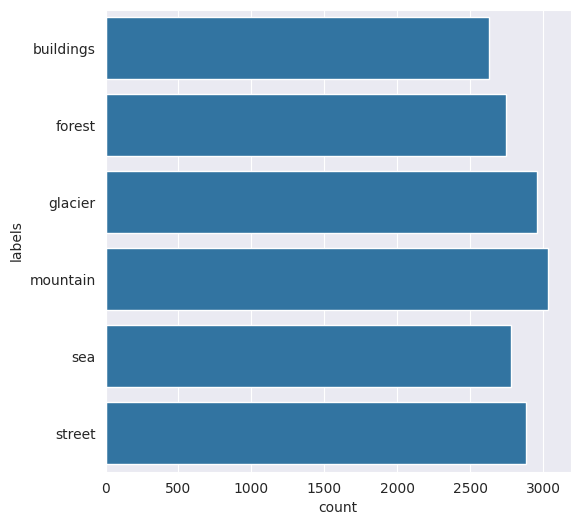

In [14]:
# Definisikan path sumber
data_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(data_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [15]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= '/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
buildings,2628
forest,2745
glacier,2957
mountain,3037
sea,2784
street,2883


#### Split Dataset

In [16]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [17]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [18]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/dataset"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/"


set    labels   
test   buildings     517
       forest        539
       glacier       600
       mountain      614
       sea           545
       street        592
train  buildings    2111
       forest       2206
       glacier      2357
       mountain     2423
       sea          2239
       street       2291
dtype: int64 


                                                    path     labels    set
7982   /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...  buildings  train
1361   /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...   mountain  train
12883  /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...   mountain  train
9045   /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...        sea  train
725    /content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/...     forest  train


In [19]:
# Iterate through the dataframe and copy images to train/test directories
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    # If the file path is invalid, it's possible the 'image' column contains the file name
    # and not the full path. In such case, construct the path using datasource_path, labels, and the file name
    if not os.path.exists(file_path):
        file_path = os.path.join(datasource_path, row['labels'], row['file_name']) # Use 'file_name' instead of 'image'

    # Check if the file exists before proceeding
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        continue  # Skip to the next iteration

    # Buat direktori tujuan folder
    os.makedirs(os.path.join(dataset_path, row['set'], row['labels']), exist_ok=True)

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Salin file dari sumber ke tujuan
    if not os.path.exists(file_dest):
        shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

In [20]:
# Definisikan direktori training dan test
TRAIN_DIR = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/train"
TEST_DIR = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/test"

train_buildings = os.path.join(TRAIN_DIR + '/buildings')
train_forest = os.path.join(TRAIN_DIR + '/forest')
test_buildings = os.path.join(TEST_DIR + '/buildings')
test_forest = os.path.join(TEST_DIR + '/forest')
train_glacier = os.path.join(TRAIN_DIR + '/glacier')
test_glacier = os.path.join(TEST_DIR + '/glacier')
train_mountain = os.path.join(TRAIN_DIR + '/mountain')
test_mountain = os.path.join(TEST_DIR + '/mountain')
train_sea = os.path.join(TRAIN_DIR + '/sea')
test_sea = os.path.join(TEST_DIR + '/sea')
train_street = os.path.join(TRAIN_DIR + '/street')
test_street = os.path.join(TEST_DIR + '/street')

print("Total number of buildings images in training set: ",len(os.listdir(train_buildings)))
print("Total number of forest images in training set: ",len(os.listdir(train_forest)))
print("Total number of glacier images in training set: ",len(os.listdir(train_glacier)))
print("Total number of mountain images in training set: ",len(os.listdir(train_mountain)))
print("Total number of sea images in training set: ",len(os.listdir(train_sea)))
print("Total number of street images in training set: ",len(os.listdir(train_street)))
print("Total number of buildings images in test set: ",len(os.listdir(test_buildings)))
print("Total number of forest images in test set: ",len(os.listdir(test_forest)))
print("Total number of glacier images in test set: ",len(os.listdir(test_glacier)))
print("Total number of mountain images in test set: ",len(os.listdir(test_mountain)))
print("Total number of sea images in test set: ",len(os.listdir(test_sea)))
print("Total number of street images in test set: ",len(os.listdir(test_street)))

Total number of buildings images in training set:  2111
Total number of forest images in training set:  2206
Total number of glacier images in training set:  2357
Total number of mountain images in training set:  2423
Total number of sea images in training set:  2239
Total number of street images in training set:  2291
Total number of buildings images in test set:  517
Total number of forest images in test set:  539
Total number of glacier images in test set:  600
Total number of mountain images in test set:  614
Total number of sea images in test set:  545
Total number of street images in test set:  592


In [21]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='categorical',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='categorical',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 10904 images belonging to 6 classes.
Found 2723 images belonging to 6 classes.
Found 3407 images belonging to 6 classes.


In [22]:
import os
from PIL import Image

def remove_corrupted_images(directory):
    removed = 0
    for root, _, files in os.walk(directory):
        for filename in files:
            file_path = os.path.join(root, filename)
            try:
                img = Image.open(file_path)
                img.verify()  # akan error jika file rusak
            except Exception as e:
                print(f"❌ Removed corrupted: {file_path} ({e})")
                os.remove(file_path)
                removed += 1
    print(f"\n✅ Total corrupted images removed: {removed}")

# Ganti ini dengan folder train dan test kamu
remove_corrupted_images(TRAIN_DIR)
remove_corrupted_images(TEST_DIR)


✅ Total corrupted images removed: 0

✅ Total corrupted images removed: 0


## Modelling

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Cek GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Bersihkan session
tf.keras.backend.clear_session()

# Path direktori
TRAIN_DIR = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/train"  # Ganti dengan path asli

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=32,  # Sesuaikan agar stabil
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

# Model CNN
model_1 = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,1), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

# Compile
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 10904 images belonging to 6 classes.
Found 2723 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,938,982 (41.73 MB)

 Trainable params: 10,938,086 (41.73 MB)

 Non-trainable params: 896 (3.50 KB)

In [24]:
# Training
history = model_1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.3860 - loss: 1.9888
Epoch 1: val_loss improved from inf to 2.75982, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 105s 261ms/step - accuracy: 0.3861 - loss: 1.9878 - val_accuracy: 0.1634 - val_loss: 2.7598 - learning_rate: 1.0000e-04
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5196 - loss: 1.3726
Epoch 2: val_loss improved from 2.75982 to 1.20716, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 82s 240ms/step - accuracy: 0.5196 - loss: 1.3725 - val_accuracy: 0.6133 - val_loss: 1.2072 - learning_rate: 1.0000e-04
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5789 - loss: 1.2526
Epoch 3: val_loss did not improve from 1.20716
341/341 ━━━━━━━━━━━━━━━━━━━━ 76s 222ms/step - accuracy: 0.5789 - loss: 1.2526 - val_accuracy: 0.5942 - val_loss: 1.2536 - learning_rate: 1.0000e-04
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6054 - loss: 1.1954
Epoch 4: val_loss improved from 1.20716 to 0.92966, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 75s 219ms/step - accuracy: 0.6055 - loss: 1.1953 - val_accuracy: 0.7191 - val_loss: 0.9297 - learning_rate: 1.0000e-04
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6599 - loss: 1.0790
Epoch 5: val_loss improved from 0.92966 to 0.86956, saving model to best_model.h5


...

341/341 ━━━━━━━━━━━━━━━━━━━━ 72s 211ms/step - accuracy: 0.8661 - loss: 0.4599 - val_accuracy: 0.8674 - val_loss: 0.4602 - learning_rate: 2.5000e-05
Epoch 39/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8712 - loss: 0.4490
Epoch 39: val_loss did not improve from 0.46016
341/341 ━━━━━━━━━━━━━━━━━━━━ 73s 213ms/step - accuracy: 0.8712 - loss: 0.4491 - val_accuracy: 0.8652 - val_loss: 0.4761 - learning_rate: 2.5000e-05
Epoch 40/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8673 - loss: 0.4499
Epoch 40: val_loss improved from 0.46016 to 0.45834, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 72s 212ms/step - accuracy: 0.8672 - loss: 0.4499 - val_accuracy: 0.8671 - val_loss: 0.4583 - learning_rate: 2.5000e-05
Epoch 41/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8666 - loss: 0.4518
Epoch 41: val_loss did not improve from 0.45834
341/341 ━━━━━━━━━━━━━━━━━━━━ 79s 233ms/step - accuracy: 0.8666 - loss: 0.4518 - val_accuracy: 0.8627 - val_loss: 0.4600 - learning_rate: 2.5000e-05
Epoch 42/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8632 - loss: 0.4462
Epoch 42: val_loss did not improve from 0.45834
341/341 ━━━━━━━━━━━━━━━━━━━━ 72s 211ms/step - accuracy: 0.8632 - loss: 0.4462 - val_accuracy: 0.8700 - val_loss: 0.4684 - learning_rate: 2.5000e-05
Epoch 43/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8690 - loss: 0.4413
Epoch 43: val_loss did not improve from 0.45834

Epoch 43: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
341/341 ━━━━━━━━━━━━━━━━━━━━ 73s 213ms/step - accuracy: 0.8690 - lo

341/341 ━━━━━━━━━━━━━━━━━━━━ 73s 214ms/step - accuracy: 0.8712 - loss: 0.4379 - val_accuracy: 0.8604 - val_loss: 0.4579 - learning_rate: 1.2500e-05
Epoch 45/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8764 - loss: 0.4205
Epoch 45: val_loss improved from 0.45787 to 0.43875, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 73s 215ms/step - accuracy: 0.8764 - loss: 0.4205 - val_accuracy: 0.8718 - val_loss: 0.4387 - learning_rate: 1.2500e-05
Epoch 46/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8685 - loss: 0.4329
Epoch 46: val_loss did not improve from 0.43875
341/341 ━━━━━━━━━━━━━━━━━━━━ 72s 211ms/step - accuracy: 0.8685 - loss: 0.4329 - val_accuracy: 0.8740 - val_loss: 0.4471 - learning_rate: 1.2500e-05
Epoch 47/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8723 - loss: 0.4282
Epoch 47: val_loss improved from 0.43875 to 0.43778, saving model to best_model.h5


341/341 ━━━━━━━━━━━━━━━━━━━━ 73s 215ms/step - accuracy: 0.8723 - loss: 0.4282 - val_accuracy: 0.8726 - val_loss: 0.4378 - learning_rate: 1.2500e-05
Epoch 48/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8697 - loss: 0.4190
Epoch 48: val_loss did not improve from 0.43778
341/341 ━━━━━━━━━━━━━━━━━━━━ 73s 213ms/step - accuracy: 0.8697 - loss: 0.4190 - val_accuracy: 0.8729 - val_loss: 0.4384 - learning_rate: 1.2500e-05
Epoch 49/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8750 - loss: 0.4249
Epoch 49: val_loss did not improve from 0.43778
341/341 ━━━━━━━━━━━━━━━━━━━━ 79s 232ms/step - accuracy: 0.8750 - loss: 0.4249 - val_accuracy: 0.8693 - val_loss: 0.4427 - learning_rate: 1.2500e-05
Epoch 50/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8778 - loss: 0.4138
Epoch 50: val_loss did not improve from 0.43778

Epoch 50: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
341/341 ━━━━━━━━━━━━━━━━━━━━ 80s 233ms/step - accuracy: 0.8778 - los

## Evaluasi dan Visualisasi

## Konversi Model

In [46]:
model_1.export('/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/model')

Saved artifact at '/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139408838476240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408888914640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408838477008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408838476432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408838477392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408838476624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408888915408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408832796752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408832796944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139408832796368: TensorSpec(shape=(), dtype=tf.re

In [25]:
source_folder = "/content/best_model.h5"  # Replace with the actual source folder path
destination_folder = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR"  # Replace with the desired destination

# Move the folder
shutil.move(source_folder, destination_folder)


'/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/best_model.h5'

In [26]:
# Install tensorflowjs
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [39]:
os.mkdir("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tfjs_model")

In [58]:
import tensorflowjs as tfjs
from tensorflow import keras

# Load model
model = keras.models.load_model("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/best_model.h5")

# Convert to TFJS format
tfjs.converters.save_keras_model(
    model,
    "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tfjs_model"
)

failed to lookup keras version from the file,
    this is likely a weight only file


In [61]:
os.mkdir("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/saved_model")

In [62]:
tf.saved_model.save(model_1, '/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/saved_model')

In [63]:
os.mkdir("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tflite")

In [64]:
# Convert SavedModel menjadi vegs.tflite
converter = tf.lite.TFLiteConverter.from_saved_model("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/saved_model")
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/tflite/place.tflite')
tflite_model_file.write_bytes(tflite_model)

28364

In [68]:
!pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.6.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.23
albumentations==2.0.5
ale-py==0.10.2
altair==5.5.0
annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.1
arviz==0.21.0
astropy==7.0.1
astropy-iers-data==0.2025.4.21.0.37.6
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.1.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blosc2==3.3.1
bokeh==3.7.2
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
CacheControl==0.14.2
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.1.31
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.89
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.21.0
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confect

## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: buildings


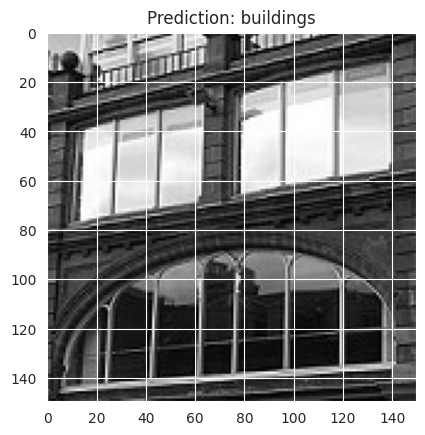

In [66]:
# Load the trained model
model = keras.models.load_model("/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/best_model.h5")

# Define the path to your validation image
image_path = "/content/drive/MyDrive/DBS/KLASIFIKASI GAMBAR/test/buildings/10126.jpg" # Example path, replace with your image

# Preprocess the image
img = Image.open(image_path).convert("L")
img = img.resize((150, 150))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
img_array = np.expand_dims(img_array, axis=-1)

# Perform inference
predictions = model.predict(img_array)

# Get the predicted class
predicted_class = np.argmax(predictions[0])

# Get class labels from the generator (assuming you have it defined)
class_labels = list(train_generator.class_indices.keys())

# Print the prediction
print(f"Predicted class: {class_labels[predicted_class]}")

# Display the image
plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {class_labels[predicted_class]}")
plt.show()
